# Spotify Hit Predictor: XGBoost Model

This is the main model notebook. I trained a separate XGBoost classifier for each of the 10 genres rather than one global model, since what makes a hit pop song is pretty different from what makes a hit metal song.

A few things worth noting:
- Used scale_pos_weight to handle class imbalance since hits are much rarer than non-hits in some genres
- Dropped key, mode, and time_signature after seeing they weren't helping the models
- Also tried regression to predict exact popularity scores but the R2 values were really low, turns out audio features can tell you if a song has the right qualities but not how famous it'll get

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv("Top_10_genres_Spotify_Music.csv")
genres = df['track_genre'].unique()

print(f"Dataset Loaded! Total rows: {len(df)}")
print(f"Targeting {len(genres)} unique genres: {', '.join(genres).title()}")

Dataset Loaded! Total rows: 7999
Targeting 10 unique genres: Emo, Pop, Grunge, Chill, K-Pop, Sad, Pop-Film, Indian, Anime, Sertanejo


In [ ]:
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit
0,57,120058,1,0.708,0.235,11,-16.156,0,0.3180,0.77200,0.002380,0.1030,0.1690,139.998,4,emo,1
1,4,158391,0,0.869,0.726,11,-5.654,0,0.0459,0.07840,0.000000,0.1070,0.3430,124.023,4,pop,0
2,44,380306,0,0.473,0.858,1,-4.982,0,0.0533,0.00156,0.242000,0.1150,0.0439,124.987,4,grunge,0
3,73,195200,1,0.768,0.374,7,-12.490,1,0.7230,0.28800,0.000002,0.1110,0.3980,75.503,4,chill,1
4,58,264538,0,0.458,0.384,8,-5.045,1,0.0267,0.73400,0.000000,0.0985,0.1570,148.210,3,k-pop,1


In [ ]:
genres = df['track_genre'].unique()
print(f"Total rows: {len(df)}")
genre_counts = df['track_genre'].value_counts()
print(genre_counts)


Total rows: 7999
track_genre
anime        824
emo          816
grunge       815
pop          813
chill        810
pop-film     795
k-pop        788
sad          781
sertanejo    779
indian       778
Name: count, dtype: int64


## Dropping Features That Weren't Helping

Before training our models, we must curate our feature set. Features like `key`, `mode`, and `time_signature` are musically structural, but they are often mathematically noisy for tree-based models because they don't have a continuous relationship with popularity. By dropping these, we force our models to focus strictly on the sonic textures (like energy, danceability, acousticness) that drive human engagement.

In [ ]:
# Drop features that add noise rather than predictive power
features_to_drop = ['key', 'mode', 'time_signature']
df = df.drop(columns=features_to_drop)

print(f"Removed useless features: {features_to_drop}")
print(f"Remaining features for prediction: {df.columns.drop(['popularity', 'track_genre', 'is_hit']).tolist()}")

Removed useless features: ['key', 'mode', 'time_signature']
Remaining features for prediction: ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


## Training One Model Per Genre
For each of the 10 genres, we train an **XGBClassifier** to predict if a song crosses the threshold of becoming a Hit (popularity $\ge$ 50). We use `scale_pos_weight` to dynamically handle any class imbalances within specific genres.

In [ ]:
from sklearn.metrics import recall_score, accuracy_score #

genre_metrics_clf = []
genre_importances = {}
genre_recommendations = {}

for genre in genres:
    subset = df[df['track_genre'] == genre]
    X = subset.drop(columns=['popularity', 'track_genre', 'is_hit'])
    y_clf = subset['is_hit']

    # Split and Scale
    X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)
    binary_cols = [c for c in X.columns if X[c].nunique() == 2]
    numeric_cols = [c for c in X.columns if c not in binary_cols]

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    # Train XGBClassifier
    num_ones = np.sum(y_train_clf == 1)
    num_zeros = np.sum(y_train_clf == 0)
    imbalance_ratio = float(num_zeros) / num_ones if num_ones > 0 else 1.0

    xgb_clf = xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=4,
        scale_pos_weight=imbalance_ratio, random_state=42, eval_metric='logloss'
    )
    xgb_clf.fit(X_train_scaled, y_train_clf)

    # Evaluate
    y_prob = xgb_clf.predict_proba(X_test_scaled)[:, 1]
    y_pred = xgb_clf.predict(X_test_scaled)

    auc_score = roc_auc_score(y_test_clf, y_prob) if len(np.unique(y_test_clf)) > 1 else np.nan
    recall = recall_score(y_test_clf, y_pred) if len(np.unique(y_test_clf)) > 1 else np.nan
    accuracy = accuracy_score(y_test_clf, y_pred) if len(np.unique(y_test_clf)) > 1 else np.nan

    # Extract Features
    importances = xgb_clf.feature_importances_
    fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
    genre_importances[genre] = fi_df
    genre_recommendations[genre] = fi_df['Feature'].head(3).tolist()

    genre_metrics_clf.append({
        'Genre': genre.replace("-", " ").title(),
        'ROC-AUC': auc_score,
        'Recall': recall,
        'Accuracy': accuracy
    })



In [ ]:
# Display Performance
metrics_df = pd.DataFrame(genre_metrics_clf).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("="*70)
print("CLASSIFICATION PERFORMANCE".center(70))
print("="*70)
print(f"{'Genre':<20} | {'ROC-AUC':<12} | {'Recall':<12} | {'Accuracy':<12}") # <-- ADDED Accuracy Header
print("-" * 70)
for index, row in metrics_df.iterrows():
    print(f"{row['Genre']:<20} | {row['ROC-AUC']:<12.4f} | {row['Recall']:<12.4f} | {row['Accuracy']:<12.4f}") # <-- ADDED Accuracy Data
print("======================================================================")

                      CLASSIFICATION PERFORMANCE                      
Genre                | ROC-AUC      | Recall       | Accuracy    
----------------------------------------------------------------------
Pop                  | 0.8899       | 0.8318       | 0.8221      
Pop Film             | 0.8557       | 0.8758       | 0.8553      
Emo                  | 0.7588       | 0.7835       | 0.7195      
K Pop                | 0.7401       | 0.7156       | 0.6962      
Anime                | 0.7191       | 0.6429       | 0.6424      
Sad                  | 0.6302       | 0.6983       | 0.6433      
Grunge               | 0.6252       | 0.6804       | 0.5828      
Chill                | 0.6148       | 0.7634       | 0.6914      
Sertanejo            | 0.5538       | 0.3409       | 0.6154      
Indian               | 0.5498       | 0.4918       | 0.5385      


## Visualizing Top Hit Drivers by Genre

To advise our artists, we extract the internal feature weights from our classifiers. This 5x2 grid displays the most important audio features for predicting a Hit in every genre.

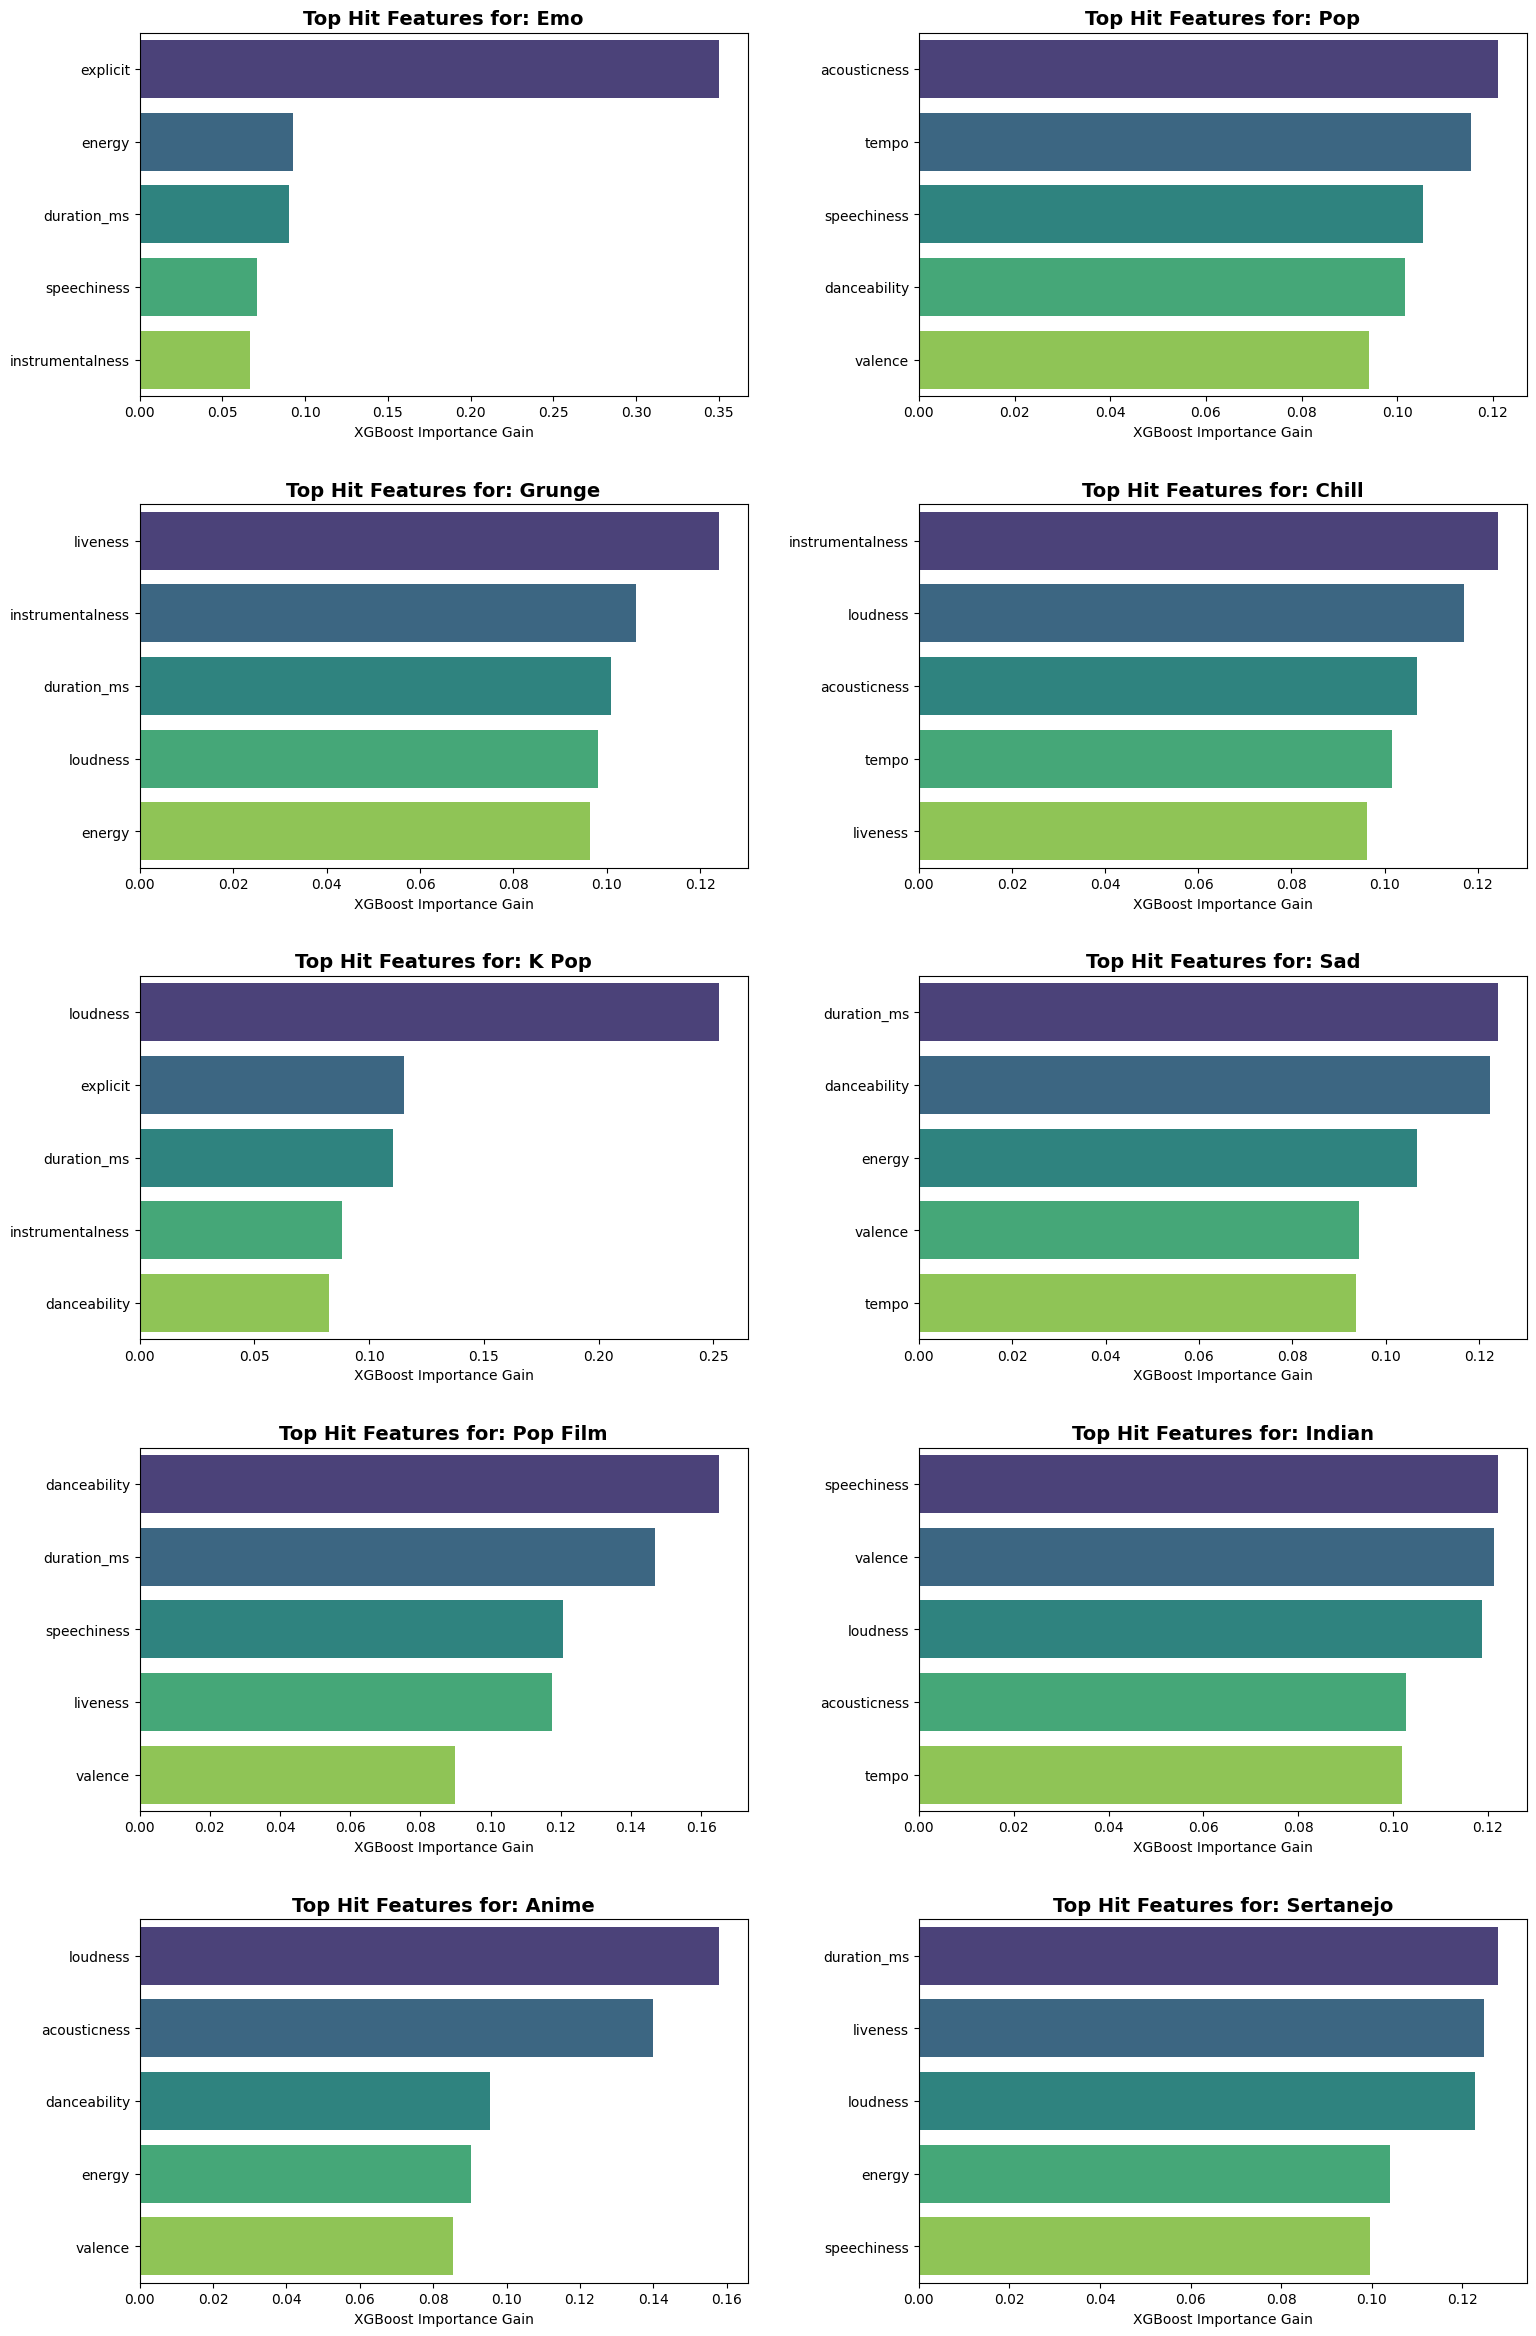

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, genre in enumerate(genres):
    fi_df = genre_importances[genre]
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(5), ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Hit Features for: {genre.replace("-", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('XGBoost Importance Gain')
    axes[i].set_ylabel('')

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
# 1. Create a list to store the row data for our table
top_features_table = []

for genre in genres:
    # Get the feature importance dataframe we saved earlier for this genre
    fi_df = genre_importances[genre]

    # Extract the top 5 features
    top_5 = fi_df['Feature'].head(5).tolist()

    # Clean up the feature names so they look professional in the table
    clean_top_5 = [f.replace("_", " ").title() for f in top_5]

    # Add the genre name as the first item, followed by its top 5 features
    row_data = [genre.replace("-", " ").title()] + clean_top_5
    top_features_table.append(row_data)

# 2. Convert the list into a Pandas DataFrame
top_features_df = pd.DataFrame(
    top_features_table,
    columns=['Genre', '1st Feature', '2nd Feature', '3rd Feature', '4th Feature', '5th Feature']
)

# 3. Display the clean table
print("="*95)
print("TOP 5 AUDIO FEATURES BY GENRE".center(95))
print("="*95)

# Use display() instead of print() to render a beautiful HTML table in Google Colab
display(top_features_df)

print("===============================================================================================")

                                 TOP 5 AUDIO FEATURES BY GENRE                                 


,Genre,1st Feature,2nd Feature,3rd Feature,4th Feature,5th Feature
0,Emo,Explicit,Energy,Duration Ms,Speechiness,Instrumentalness
1,Pop,Acousticness,Tempo,Speechiness,Danceability,Valence
2,Grunge,Liveness,Instrumentalness,Duration Ms,Loudness,Energy
3,Chill,Instrumentalness,Loudness,Acousticness,Tempo,Liveness
4,K Pop,Loudness,Explicit,Duration Ms,Instrumentalness,Danceability
5,Sad,Duration Ms,Danceability,Energy,Valence,Tempo
6,Pop Film,Danceability,Duration Ms,Speechiness,Liveness,Valence
7,Indian,Speechiness,Valence,Loudness,Acousticness,Tempo
8,Anime,Loudness,Acousticness,Danceability,Energy,Valence
9,Sertanejo,Duration Ms,Liveness,Loudness,Energy,Speechiness


## Universal Audio Features Across All Genres


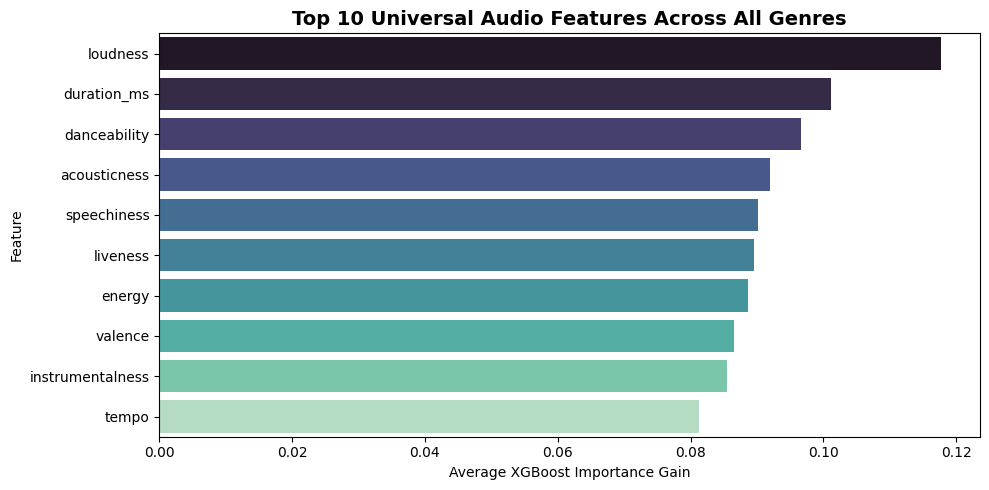

In [ ]:
# Calculate and Plot Global Ranking
all_importances = pd.concat(genre_importances.values())
global_importances = all_importances.groupby('Feature')['Importance'].mean().reset_index()
global_importances = global_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=global_importances.head(10), palette='mako')
plt.title('Top 10 Universal Audio Features Across All Genres', fontsize=14, fontweight='bold')
plt.xlabel('Average XGBoost Importance Gain')
plt.tight_layout()
plt.show()

## Overall Platform Performance

To conclude our primary analysis, we want to summarize the overall success of our classification models across the entire platform. By averaging the performance of our 10 genre-specific models, we can confidently state how reliable our audio blueprints are.

In [ ]:
# Calculate Overall Performance Metrics
overall_auc = metrics_df['ROC-AUC'].mean()
overall_recall = metrics_df['Recall'].mean()

print("="*65)
print("OVERALL CLASSIFICATION PERFORMANCE".center(65))
print("="*65)
print(f"Across all 10 top Spotify genres, our XGBoost models achieved:\n")
print(f"Average ROC-AUC Score : {overall_auc:.4f}")
print(f"Average Hit Recall    : {overall_recall:.4f} \n")



                OVERALL CLASSIFICATION PERFORMANCE               
Across all 10 top Spotify genres, our XGBoost models achieved:

Average ROC-AUC Score : 0.6937
Average Hit Recall    : 0.6824 



## Why We Can't Predict Exact Popularity Scores
While our Classification models successfully identify the audio blueprint of a Hit, can we predict the **exact popularity score (0-100)** of a song using only audio features?

To test this, we trained 10 genre-specific **XGBoost Regressors**.

**Conclusion:** The resulting $R^2$ values are extremely low (often near zero or negative). This proves a crucial limitation in music data analytics: **Audio features act as a gatekeeper for a good song, but a track's exact popularity score is ultimately determined by external, out-of-dataset factors** (e.g., Artist fame, marketing budgets, record label backing, and algorithmic playlist placements).

In [ ]:
genre_metrics_reg = []

for genre in genres:
    subset = df[df['track_genre'] == genre]
    X = subset.drop(columns=['popularity', 'track_genre', 'is_hit'])
    y_reg = subset['popularity']

    # Split and Scale
    X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
    binary_cols = [c for c in X.columns if X[c].nunique() == 2]
    numeric_cols = [c for c in X.columns if c not in binary_cols]

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    # Train Heavily Regularized XGBRegressor
    xgb_reg = xgb.XGBRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=4,
        min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=5, reg_lambda=15, random_state=42, eval_metric='rmse'
    )
    xgb_reg.fit(X_train_scaled, y_train_reg)

    # Evaluate
    y_pred_reg = xgb_reg.predict(X_test_scaled)
    rmse_score = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)

    genre_metrics_reg.append({
        'Genre': genre.replace("-", " ").title(),
        'RMSE': rmse_score,
        'R-Squared': r2
    })

# Display Appendix Limitations Table
metrics_df_reg = pd.DataFrame(genre_metrics_reg).sort_values(by='R-Squared', ascending=False).reset_index(drop=True)

print("="*60)
print("APPENDIX: REGRESSION LIMITATIONS".center(60))
print("="*60)
print(f"{'Genre':<20} | {'RMSE (Avg Error)':<18} | {'R-Squared':<10}")
print("-" * 60)
for index, row in metrics_df_reg.iterrows():
    print(f"{row['Genre']:<20} | {row['RMSE']:<18.2f} | {row['R-Squared']:<10.4f}")
print("============================================================")
print("Insight: The low R-Squared values prove that audio features")
print("alone cannot predict exact popularity scores.")

              APPENDIX: REGRESSION LIMITATIONS              
Genre                | RMSE (Avg Error)   | R-Squared 
------------------------------------------------------------
Pop                  | 23.71              | 0.4882    
K Pop                | 15.74              | 0.2839    
Emo                  | 15.39              | 0.2099    
Pop Film             | 8.52               | 0.1734    
Sad                  | 8.75               | 0.1562    
Anime                | 9.84               | 0.1529    
Grunge               | 16.99              | 0.0674    
Indian               | 12.03              | 0.0320    
Sertanejo            | 3.97               | -0.0038   
Chill                | 14.26              | -0.0193   
Insight: The low R-Squared values prove that audio features
alone cannot predict exact popularity scores.
